# Constraint-adaptive scheduling: pilot analysis

## Context & Methods

This notebook audits the immutable assisted-synthesis pilot. It separates designed diagnostics, random temporal problems, and original C3-derived local subproblems. A single frozen program is applied to each test context. There were **zero automated LLM API calls**; candidates comprise current-assistant proposals and a deterministic enumeration. Shared-bank selection is an ablation, not independent free-form LLM synthesis.

### Key assumptions

The objective is the saved graph MWIS model. All reference bounds are checked for exactness. Paired bootstrap resamples problem pairs, keeping both configurations together; intervals describe this small sample, not a representative satellite workload population. Latency is a single local-machine observation and is not a robust hardware benchmark.

In [1]:
from pathlib import Path
import json, hashlib, collections
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
root = Path.cwd()
if not (root / "cipheur").exists():
    root = next(p for p in Path.cwd().parents if (p / "cipheur").exists())
run = root / 'experiments/runs/pilot_v0.2.0_audited'
read = lambda name: json.loads((run / name).read_text(encoding="utf-8"))
rows, summary = read("test_metrics.json"), read("summary.json")
assessments, receipt = read("candidate_assessments.json"), read("result_receipt.json")
bank = read("candidate_bank.json")
for name, expected in receipt.items():
    assert hashlib.sha256((run / name).read_bytes()).hexdigest() == expected, name
assert all(r["feasible"] and r["reference_exact"] for r in rows)
assert read("freeze_receipt.json")["automated_llm_calls"] == 0
assert all(r["feasible"] for r in read("legacy_verification.json"))
analysis = root / "experiments" / "analysis"
figures = root / "paper" / "figures"
analysis.mkdir(exist_ok=True, parents=True)
figures.mkdir(exist_ok=True, parents=True)
plt.rcParams.update({"font.size": 8, "axes.spines.top": False, "axes.spines.right": False,
                     "pdf.fonttype": 42, "savefig.dpi": 220})
print("Verified saved bytes, reference exactness, graph feasibility and original C3 verifier.")

Verified saved bytes, reference exactness, graph feasibility and original C3 verifier.


## Data

The train, validation and test splits each contain 36 pairs: 12 designed diagnostic pairs, 16 random temporal pairs, and 8 C3-derived pairs. Contact instances and intervention targets are disjoint across these splits; C3 shares only its declared reference configuration. The audited run re-executes the preliminary run after audit-only fixes, using the same candidate bank and settings; it is not an additional independent test.

In [2]:
specs = read("train_specifications.json")
test_specs = read("test_specifications.json")
counts = collections.Counter((s["family"], s["relation"]) for s in specs)
print("Training relations:", dict(counts))
print("Initial exact self-loop requirements:", read("initial_diagnosis.json")["self_loop_requirements"])
print("Test certified pairs:", len(test_specs))
print("Reference problems:", len(read("test_reference_bounds.json")))
print("Candidate pools:", read("selection.json")["pool_sizes"])
print("Selected programs:", summary["selection_names"])

Training relations: {('diagnostic', 'reversal'): 8, ('diagnostic', 'preservation'): 2, ('random_temporal', 'preservation'): 16, ('c3', 'preservation'): 8}
Initial exact self-loop requirements: 20
Test certified pairs: 34
Reference problems: 72
Candidate pools: {'shared_bank': 48, 'eligible': 30, 'targeted': 30, 'rule_only': 18, 'non_llm_enumeration': 34}
Selected programs: {'targeted_joint': 'enum_discount_0.6_1.0', 'free_joint': 'enum_discount_0.6_1.0', 'quality_only_joint': 'enum_discount_0.6_1.0', 'rule_only': 'base_degree_0.6', 'non_llm_enumeration': 'enum_discount_0.6_1.0', 'weight': 'weight', 'weight_degree': 'weight_degree', 'weighted_conflict': 'weighted_conflict'}


## Results

### Schedule reward by family

Ratios use the exact optimum for each saved residual problem. Designed probes are shown separately because their construction tests mechanism behavior rather than estimating natural-workload prevalence.

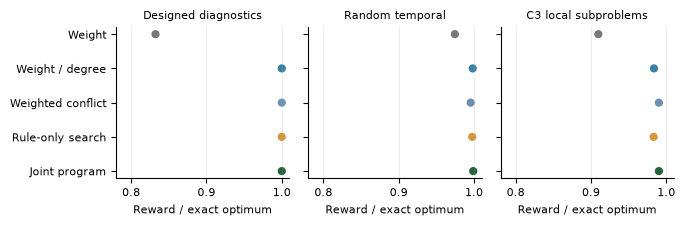

| Method | Diagnostic | Random | C3 | Strict requirements | Work | ms/context |
|---|---:|---:|---:|---:|---:|---:|
| Weight | 0.8324 | 0.9746 | 0.9098 | 44/68 | 8320 | 3.32 |
| Weight / degree | 1.0000 | 0.9983 | 0.9836 | 46/68 | 11530 | 4.47 |
| Weighted conflict | 1.0000 | 0.9955 | 0.9902 | 45/68 | 11842 | 4.44 |
| Rule-only search | 1.0000 | 0.9976 | 0.9832 | 45/68 | 11139 | 3.79 |
| Joint program | 1.0000 | 0.9989 | 0.9902 | 67/68 | 12235 | 4.74 |


In [3]:
methods = ["weight", "weight_degree", "weighted_conflict", "rule_only", "targeted_joint"]
labels = {"weight": "Weight", "weight_degree": "Weight / degree", "weighted_conflict": "Weighted conflict",
          "rule_only": "Rule-only search", "targeted_joint": "Joint program"}
families = ["diagnostic", "random_temporal", "c3"]
family_labels = ["Designed diagnostics", "Random temporal", "C3 local subproblems"]
colors = ["#777777", "#3b80a3", "#6c90b2", "#d3973f", "#25633b"]
fig, axes = plt.subplots(1, 3, figsize=(6.9, 2.3), sharey=True)
for ax, family, title in zip(axes, families, family_labels):
    values = [summary["test"][m][family]["mean_ratio"] for m in methods]
    ax.scatter(values, range(len(methods)), c=colors, s=24)
    ax.set_xlim(.78, 1.01)
    ax.set_xticks([.8, .9, 1.0])
    ax.set_yticks(range(len(methods)), [labels[m] for m in methods])
    ax.invert_yaxis()
    ax.set_title(title, fontsize=8)
    ax.set_xlabel("Reward / exact optimum")
    ax.grid(axis="x", alpha=.22)
fig.tight_layout()
fig.savefig(figures / "pilot_quality.pdf")
fig.savefig(figures / "pilot_quality.png")
display(fig)
plt.close(fig)
table = "| Method | Diagnostic | Random | C3 | Strict requirements | Work | ms/context |\n|---|---:|---:|---:|---:|---:|---:|\n"
for m in methods:
    s, spec = summary["test"][m], summary["specifications"][m]
    table += f"| {labels[m]} | {s['diagnostic']['mean_ratio']:.4f} | {s['random_temporal']['mean_ratio']:.4f} | {s['c3']['mean_ratio']:.4f} | {spec['passed']}/{spec['total']} | {s['all']['mean_feature_work']:.0f} | {1000*s['all']['mean_seconds']:.2f} |\n"
display(Markdown(table))

### Paired differences and uncertainty

The comparison below uses pair means, not 72 independent configuration observations. Small heterogeneous samples and shared resources limit population-level interpretation.

In [4]:
rng = np.random.default_rng(read("config.json")["bootstrap_seed"])
paired = {}
for r in rows:
    paired.setdefault((r["family"], r["id"], r["method"]), []).append(r["ratio"])
intervals = {}
for family in families:
    ids = sorted({r["id"] for r in rows if r["family"] == family})
    delta = np.array([np.mean(paired[family, i, "targeted_joint"]) - np.mean(paired[family, i, "rule_only"]) for i in ids])
    samples = rng.choice(delta, size=(read("config.json")["bootstrap_replicates"], len(delta)), replace=True).mean(axis=1)
    intervals[family] = {"pairs": len(ids), "mean_difference": float(delta.mean()),
                         "descriptive_95_percentile_interval": [float(x) for x in np.quantile(samples, [.025, .975])]}
print(json.dumps(intervals, indent=2))
report = {"run": str(run.relative_to(root)), "quality": summary["test"], "paired_differences": intervals,
          "strict_requirements": {m: {k: v for k,v in s.items() if k != "checks"} for m,s in summary["specifications"].items()},
          "claim_scope": "Small prototype; no demonstrated advantage of targeted guidance or LLM over shared-bank enumeration"}
(analysis / "pilot_report.json").write_text(json.dumps(report, indent=2) + "\n", encoding="utf-8")

{
  "diagnostic": {
    "pairs": 12,
    "mean_difference": 0.0,
    "descriptive_95_percentile_interval": [
      0.0,
      0.0
    ]
  },
  "random_temporal": {
    "pairs": 16,
    "mean_difference": 0.0012914038759549301,
    "descriptive_95_percentile_interval": [
      -0.0003712871287128716,
      0.003839216135648839
    ]
  },
  "c3": {
    "pairs": 8,
    "mean_difference": 0.006945522326186185,
    "descriptive_95_percentile_interval": [
      -0.0015808943504911493,
      0.017841319612441273
    ]
  }
}


10358

### Representation consistency and feature cost

Feature work is the declared deterministic operation proxy measured over complete schedules. It includes the base representation and changes in schedule length; it is not an isolated cost per feature or CPU instruction count.

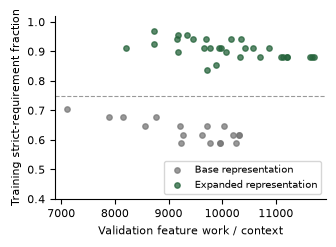

Remaining held-out strict violations: [{'specification': 'random_temporal_test_0014', 'side': 'right', 'relation': 'reversal', 'preferred': 'n_339c5535', 'scores': {'n_0144887a': -3.3999999999999995, 'n_339c5535': -3.4375}, 'passed': False}]


370

In [5]:
fig, ax = plt.subplots(figsize=(3.4, 2.45))
for expanded, color, label in [(False, "#777777", "Base representation"), (True, "#25633b", "Expanded representation")]:
    part = [a for a in assessments if bool(bank["candidates"][a["candidate"]]["features"]) == expanded]
    ax.scatter([a["feature_work"] for a in part], [a["spec_fraction"] for a in part], c=color, s=15, alpha=.75, label=label)
ax.axhline(.75, color="#999999", linestyle="--", linewidth=.8)
ax.set_xlabel("Validation feature work / context")
ax.set_ylabel("Training strict-requirement fraction")
ax.set_ylim(0.4, 1.02)
ax.legend(fontsize=7, loc="lower right")
fig.tight_layout()
fig.savefig(figures / "pilot_consistency_cost.pdf")
fig.savefig(figures / "pilot_consistency_cost.png")
display(fig)
plt.close(fig)
assert summary["selection_names"]["targeted_joint"] == summary["selection_names"]["free_joint"] == summary["selection_names"]["non_llm_enumeration"]
failed = [c for c in summary["specifications"]["targeted_joint"]["checks"] if not c["passed"]]
print("Remaining held-out strict violations:", failed)
lines = [r"\begin{tabular}{lrrrr}", r"\toprule", "Method & Diag. & Random & C3 & Strict " + chr(92)*2, r"\midrule"]
for m in methods:
    s, spec = summary["test"][m], summary["specifications"][m]
    lines.append(f"{labels[m]} & {s['diagnostic']['mean_ratio']:.4f} & {s['random_temporal']['mean_ratio']:.4f} & {s['c3']['mean_ratio']:.4f} & {spec['passed']}/{spec['total']} " + chr(92)*2)
lines += [r"\bottomrule", r"\end{tabular}"]
(root / "paper" / "results_table.tex").write_text("\n".join(lines) + "\n", encoding="utf-8")

## Further experiment: additional frozen-program evaluation

The same programs are evaluated on new instance identities after the pilot. They are never revised from those outcomes. The primary pilot and follow-up reuse resource configurations; the follow-up isolates additional instance transfer rather than claiming a further configuration shift.

In [6]:
follow_path = root / "experiments" / "runs" / "followup_v0.2.0"
follow = json.loads((follow_path / "summary.json").read_text(encoding="utf-8"))
for name, expected in json.loads((follow_path / "result_receipt.json").read_text(encoding="utf-8")).items():
    assert hashlib.sha256((follow_path / name).read_bytes()).hexdigest() == expected
assert (follow_path / "frozen_programs.json").read_bytes() == (run / "frozen_programs.json").read_bytes()
display(Markdown("| Method | Overall | Random | C3 | Strict |\n|---|---:|---:|---:|---:|\n" + "\n".join(
    f"| {labels[m]} | {follow['test'][m]['all']['mean_ratio']:.4f} | {follow['test'][m]['random_temporal']['mean_ratio']:.4f} | {follow['test'][m]['c3']['mean_ratio']:.4f} | {follow['specifications'][m]['passed']}/{follow['specifications'][m]['total']} |" for m in methods)))

| Method | Overall | Random | C3 | Strict |
|---|---:|---:|---:|---:|
| Weight | 0.9012 | 0.9703 | 0.9042 | 38/64 |
| Weight / degree | 0.9973 | 0.9976 | 0.9921 | 41/64 |
| Weighted conflict | 0.9973 | 0.9995 | 0.9877 | 41/64 |
| Rule-only search | 0.9974 | 0.9973 | 0.9934 | 41/64 |
| Joint program | 0.9968 | 0.9988 | 0.9868 | 61/64 |

## Takeaways

The pilot joint program reaches mean ratio **0.9973**, compared with **0.9952** for the selected rule-only control, with strict held-out consistency **67/68**. The follow-up reverses the overall quality comparison: **0.9968** joint versus **0.9974** rule-only, especially C3 **0.9868** versus **0.9934**. Joint strict consistency remains higher at **61/64** versus **41/64**. These findings do not establish uniform schedule superiority.

The base representation has 20 exact self-loop requirements among 68 training inequalities. A pointwise score of that representation cannot satisfy those 20 strict comparisons, yet a greedy schedule can choose peripheral contacts first and change the residual state, producing an optimal schedule despite those initial ties. Strict-ranking adequacy is a different property from complete-schedule quality.

Targeted, free-joint, quality-only and non-LLM enumeration select the **same program**. This pilot validates the executable evidence/representation path and cannot establish a targeted-search or LLM advantage. Independent matched-budget generation runs remain required.